In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Use this notebook to build and visualize a Spice Co-occurrence Network from recipe data, using cosine weights, Louvain communities, auto-pruning by edge-weight quantiles, and Top-K neighbor thinning. Saves reproducible artifacts (graph, nodes/communities CSV, edges CSV).

In [ ]:
# Ensure the Louvain package is installed (required, no fallback).
!pip -q install python-louvain

Import libraries and define all configuration (paths, thresholds, plotting, reproducibility).

In [ ]:
# ---------------- Imports ----------------
import math, itertools, re, textwrap
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from collections import defaultdict

# We explicitly require 'python-louvain' to make the method unambiguous and reproducible.
try:
    from community import community_louvain as louvain
except Exception as e:
    raise RuntimeError(
        "This analysis requires 'python-louvain'. Install with: pip install python-louvain"
    ) from e


# ---------------- Configuration ----------------
# Path to the database that was created during the web crawling
CSV_PATH = "/content/drive/MyDrive/Data Mining - Final Project/recipes_spices.csv"

# --- Filtering thresholds ---
MIN_RECIPES_PER_SPICE = 5   # keep spices that appear in at least 5 recipes.
MIN_CO = 2  # Ignore spice pairs that co-occur in less than 2 recipes.

# --- Auto-prune parameters ---
# controls sparsity. Higher quantiles prune more edges.
# We select the quantile that maximizes the number of communities while forbidding size-1 communities.
QUANTILES = np.linspace(0.20, 0.90, 15)
MIN_COMMUNITY_SIZE = 2      # Disallow single-node communities

# --- Graph readability ---
TOPK = 3                    # Keep only top-k strongest neighbors per node

# --- Plotting ---
PLOT_DROP_ISOLATES = True   # For clarity, hide isolated nodes in the plot (still saved to files)
LABEL_FONT = 9
RAND_SEED = 42               # For stable layouts and Louvain randomization

# --- Output paths ---
OUT_GRAPH     = "/content/drive/MyDrive/Data Mining - Final Project/Visualization 2 - Classification/spice_graph.gpickle"
OUT_PARTITION = "/content/drive/MyDrive/Data Mining - Final Project/Visualization 2 - Classification/spice_partition.csv"
OUT_EDGES     = "/content/drive/MyDrive/Data Mining - Final Project/Visualization 2 - Classification/spice_edges.csv"


# Make plots a bit sharper in Colab
%config InlineBackend.figure_format = 'retina'

Load the CSV, deduplicate (recipe, spice), and keep only spices that appear often enough.

In [ ]:
# Load Data & Preprocess
df = pd.read_csv(CSV_PATH)

# Ensure required columns exist.
needed = {"recipe_url", "spice"}
missing = needed - set(df.columns)
if missing:
    raise ValueError(f"CSV missing required columns: {missing}")

# Deduplicate to a set of unique (recipe, spice) pairs to avoid counting duplicates twice
dfu = df.drop_duplicates(subset=["recipe_url", "spice"])

# Map each spice -> set of recipe URLs where it appears
by_spice_all = dfu.groupby("spice")["recipe_url"].apply(set).to_dict()

# Keep spices that appear in enough recipes (frequency filter)
by_spice = {s: R for s, R in by_spice_all.items() if len(R) >= MIN_RECIPES_PER_SPICE}
if not by_spice:
    raise RuntimeError("No spices passed MIN_RECIPES_PER_SPICE. Lower the threshold and retry.")

# Node attribute: number of recipes per spice (used later for node sizing)
nodes = {s: len(R) for s, R in by_spice.items()}

print(f"Loaded {len(df):,} rows; {len(by_spice_all):,} total spices; {len(by_spice):,} kept after frequency filter.")


Loaded 9,009 rows; 72 total spices; 54 kept after frequency filter.


Build raw co-occurrence edges with cosine weights, pruning pairs with very small overlaps.

In [ ]:
# Build Co-occurrence Edges (Cosine Weights)
def cosine_weight(co, na, nb):
    """
    Cosine-like co-occurrence weight:
        w_ab = co / sqrt(n_a * n_b)
    where:
      co = |recipes(a) ∩ recipes(b)|
      n_a = |recipes(a)|, n_b = |recipes(b)|
    This normalizes by spice popularity so very common spices don't dominate edges.
    """
    return co / math.sqrt(na * nb)

raw_edges = []
# Consider all spice pairs (a, b); compute intersection size and cosine weight.
for a, b in itertools.combinations(sorted(by_spice), 2):
    Ra, Rb = by_spice[a], by_spice[b]
    co = len(Ra & Rb)            # co-occurrence count
    if co < MIN_CO:              # prune very weak co-occurrences early
        continue
    w = cosine_weight(co, len(Ra), len(Rb))
    if w > 0:
        raw_edges.append((a, b, co, w))

if not raw_edges:
    raise RuntimeError("No edges constructed. Try lowering MIN_RECIPES_PER_SPICE or MIN_CO.")

print(f"Constructed {len(raw_edges):,} raw edges before quantile pruning / Top-K.")

Constructed 644 raw edges before quantile pruning / Top-K.


Define helper functions for Top-K thinning, graph building, Louvain detection, partition evaluation, edge-width scaling, and a community-aware layout.

In [ ]:
# Helper Functions
def topk_edges_per_node(edges, k=TOPK):
    """
    Keep an undirected edge (u, v) if it is among the top-k strongest (by weight)
    neighbors of u OR among the top-k strongest neighbors of v.
    This preserves the locally strongest structure around each spice and improves readability.
    """
    nbrs = defaultdict(list)
    for u, v, co, w in edges:
        nbrs[u].append((v, w, co))
        nbrs[v].append((u, w, co))
    keep = set()
    for u, lst in nbrs.items():
        # Sort neighbors by weight descending and take top-k
        for v, w, _ in sorted(lst, key=lambda x: x[1], reverse=True)[:k]:
            keep.add(tuple(sorted((u, v))))
    # Return only edges whose sorted endpoints are in 'keep'
    return [(u, v, co, w) for (u, v, co, w) in edges if tuple(sorted((u, v))) in keep]

def build_graph(edge_list):
    """Build a NetworkX Graph with node attribute 'n_recipes' and edge attrs 'co', 'weight'."""
    G = nx.Graph()
    for s, n in nodes.items():
        G.add_node(s, n_recipes=n)
    for (u, v, co, w) in edge_list:
        G.add_edge(u, v, co=co, weight=w)
    return G

def detect_communities_louvain(G_connected, seed=RAND_SEED):
    """
    Run Louvain community detection on a connected (sub)graph.
    Returns a dict: node -> community id
    """
    if G_connected.number_of_edges() == 0 or G_connected.number_of_nodes() < 2:
        return {n: 0 for n in G_connected}
    return louvain.best_partition(G_connected, weight="weight", random_state=seed)

def evaluate_partition(part):
    """
    Given a partition mapping (node -> community id),
    return (number_of_communities, minimum_community_size, sorted_sizes_desc).
    """
    cnt = defaultdict(int)
    for c in part.values():
        cnt[c] += 1
    sizes = sorted(cnt.values(), reverse=True)
    return len(cnt), (min(sizes) if sizes else 0), sizes

def scale_widths(weights, lo=0.8, hi=3.2):
    """
    Linearly scale edge widths into [lo, hi] range for plotting.
    """
    w = np.asarray(weights, dtype=float)
    if w.size == 0:
        return []
    rng = np.ptp(w)
    if rng == 0:
        return np.full_like(w, (lo+hi)/2, dtype=float)
    return lo + (hi-lo) * (w - w.min()) / rng

def community_ring_layout(G, part, seed=RAND_SEED):
    """
    Place each community on a ring (arranged around a circle);
    within each community, use a spring layout.
    This yields a readable global structure (communities separated)
    while preserving local structure inside communities.
    """
    rng = np.random.default_rng(seed)
    comm2nodes = defaultdict(list)
    for n, c in part.items():
        if c == -1:
            continue
        comm2nodes[c].append(n)
    comm_ids = sorted(comm2nodes.keys())
    if not comm_ids:
        return nx.spring_layout(G, seed=seed)

    # Place community centers evenly on a big circle
    R = 3.0
    theta = np.linspace(0, 2*np.pi, len(comm_ids), endpoint=False)
    centers = {cid: (R*math.cos(t), R*math.sin(t)) for cid, t in zip(comm_ids, theta)}

    # Position nodes within each community, then translate to that community's center
    pos = {}
    for cid in comm_ids:
        Hc = G.subgraph(comm2nodes[cid]).copy()
        k_inner = 0.9 / math.sqrt(max(len(Hc), 1))           # spring 'ideal' distance scales with community size
        pos_c = nx.spring_layout(Hc, seed=seed + cid, k=k_inner, iterations=200)
        r_c = 0.9 + 0.15 * math.sqrt(len(Hc))                # scale local radius mildly with size
        cx, cy = centers[cid]
        for n, (x, y) in pos_c.items():
            pos[n] = (cx + r_c * x, cy + r_c * y)

    # Any leftover nodes (e.g., isolates) get random positions near center
    for n in G.nodes():
        if n not in pos:
            pos[n] = (float(rng.uniform(-R, R)), float(rng.uniform(-R, R)))
    return pos

We sweep edge-weight quantiles; for each candidate threshold:
1.   Keep edges with weight >= threshold
2.   Apply Top-K neighbors per node to reduce clutter
3. Build graph; focus on connected part (drop nodes with degree==0 for community detection)
4. Run Louvain; keep only partitions where the smallest community size >= MIN_COMMUNITY_SIZE
5. Prefer the candidate with the largest number of communities (tie-break: higher quantile, i.e., sparser)

In [ ]:
# Auto-Prune: Quantile Search
ws = np.array([w for *_ , w in raw_edges], dtype=float)
best = None
best_data = None

for q in QUANTILES:
    thr = float(np.quantile(ws, q))
    kept = [(u, v, co, w) for (u, v, co, w) in raw_edges if w >= thr]
    kept = topk_edges_per_node(kept, k=TOPK)

    G_full = build_graph(kept)

    # Only the connected nodes participate in community detection (isolates later marked -1)
    connected_nodes = [n for n in G_full.nodes() if G_full.degree(n) > 0]
    if len(connected_nodes) < 2:
        continue
    G_conn = G_full.subgraph(connected_nodes).copy()

    part_conn = detect_communities_louvain(G_conn)

    n_comm, min_sz, sizes = evaluate_partition(part_conn)
    # Enforce minimum community size
    if min_sz < MIN_COMMUNITY_SIZE:
        continue

    # Objective: maximize number of communities; tie-break with higher quantile (sparser graph)
    cand = (n_comm, q)
    if (best is None) or (cand > best):
        best = cand
        best_data = (thr, kept, part_conn, G_full, G_conn)

if best_data is None:
    raise RuntimeError("No threshold produced communities of size ≥2. Adjust QUANTILES or thresholds.")

thr, kept_edges, part_conn, G_full, G_conn = best_data

# Final partition: assign -1 to isolates/unassigned nodes
final_part = {n: -1 for n in G_full.nodes()}
final_part.update(part_conn)

iso_count = sum(1 for n in G_full if G_full.degree(n) == 0)
print(
    f"Auto-prune threshold = {thr:.4f} | nodes={G_full.number_of_nodes()} | "
    f"edges={G_full.number_of_edges()} | isolates={iso_count} | communities={len(set(part_conn.values()))}"
)

Auto-prune threshold = 0.0415 | nodes=54 | edges=124 | isolates=0 | communities=7


Plot a readable community graph (ring layout between communities, spring layout within), with thicker intra-community edges and node sizes by recipe frequency.

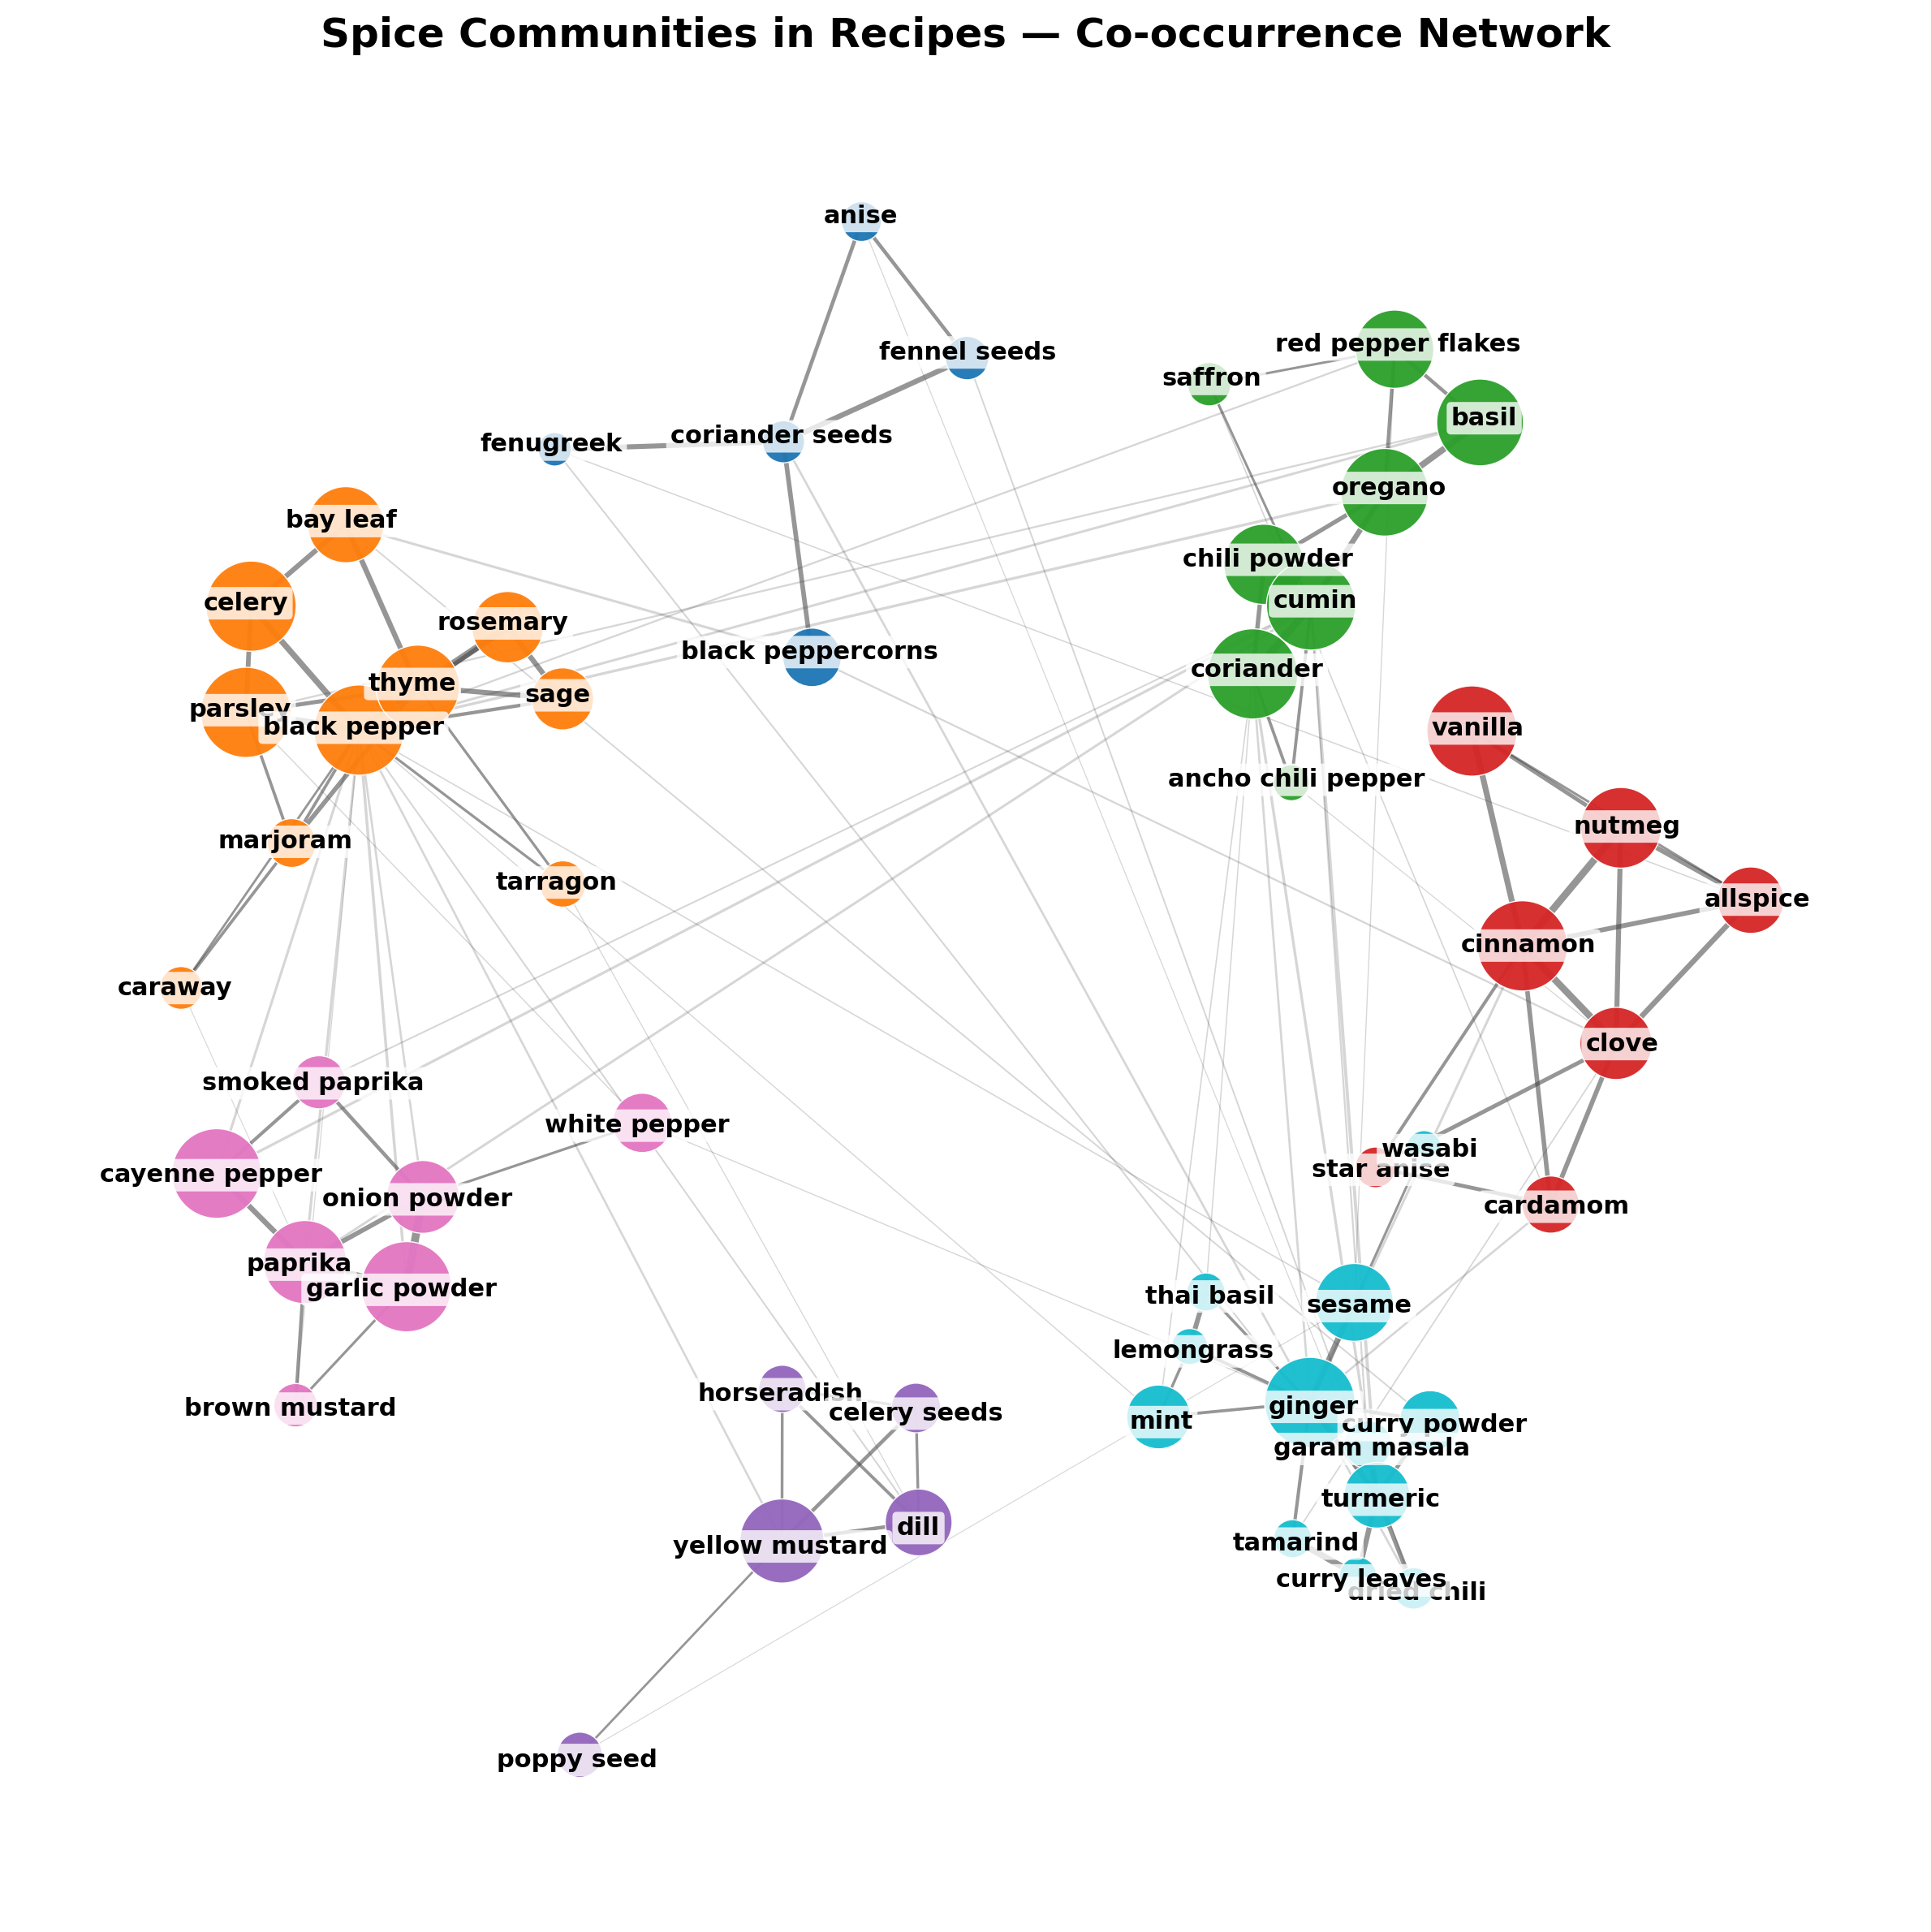

In [ ]:
# Plot the Community Graph
# Optionally drop isolates for clarity (still saved to CSVs/GPickle)
G_plot = G_full.subgraph([n for n in G_full if G_full.degree(n) > 0]).copy() if PLOT_DROP_ISOLATES else G_full

# Use the ring layout if we have at least 2 communities; otherwise a standard spring layout.
pos = (community_ring_layout(G_plot, final_part, seed=RAND_SEED)
       if len(part_conn) >= 2
       else nx.spring_layout(G_plot, seed=RAND_SEED, k=1.2 / math.sqrt(max(G_plot.number_of_nodes(), 1)), iterations=300))

fig, ax = plt.subplots(figsize=(12, 12))

# Split edges into intra-community vs inter-community for different styling (thicker within communities).
intra, inter = [], []
for u, v, d in G_plot.edges(data=True):
    cu, cv = final_part[u], final_part[v]
    (intra if (cu != -1 and cu == cv) else inter).append((u, v, d))

# Draw inter-community edges thin and semi-transparent
if inter:
    w = [float(d["weight"]) for *_, d in inter]
    nx.draw_networkx_edges(
        G_plot, pos,
        edgelist=[(u, v) for u, v, _ in inter],
        width=scale_widths(w, lo=0.4, hi=1.4),
        edge_color=(0.2, 0.2, 0.2, 0.20)
    )

# Draw intra-community edges thicker and more opaque
if intra:
    w = [float(d["weight"]) for *_, d in intra]
    nx.draw_networkx_edges(
        G_plot, pos,
        edgelist=[(u, v) for u, v, _ in intra],
        width=scale_widths(w, lo=1.0, hi=3.6),
        edge_color=(0.25, 0.25, 0.25, 0.55)
    )

# Node sizes reflect #recipes per spice (sqrt-scaled to tame extremes)
sizes = np.array([G_plot.nodes[n].get("n_recipes", 1) for n in G_plot])
sizes = np.clip((np.sqrt(sizes) * 90), 220, 1600)

# Node colors reflect community id
GROUP_COLORS = {
    1: "#D62728",  # red
    2: "#2CA02C",  # green
    3: "#1F77B4",  # blue
    4: "#FF7F0E",  # orange
    5: "#E377C2",  # pink
    6: "#9467BD",  # purple
    7: "#17BECF",  # cyan
}
zero_based = (min(final_part.values()) == 0)  # True if communities are 0..6
node_colors = [
    GROUP_COLORS.get((int(final_part[n]) + 1) if zero_based else int(final_part[n]), "#BBBBBB")
    for n in G_plot.nodes()
]

nx.draw_networkx_nodes(
    G_plot, pos,
    node_size=sizes,
    node_color=node_colors,
    alpha=0.96,
    linewidths=0.5,
    edgecolors="white"
)

# Labels slightly offset radially to avoid overlapping the node marker
offset = 0.03
for n, (x, y) in pos.items():
    r = (x**2 + y**2) ** 0.5 or 1e-9
    dx, dy = (x/r)*offset, (y/r)*offset
    plt.text(
        x+dx, y+dy, n,
        fontsize=LABEL_FONT, weight="bold",
        ha="center", va="center",
        bbox=dict(boxstyle="round,pad=0.18", fc="white", ec="none", alpha=0.78)
    )

ax.set_axis_off()
ax.set_title(
    "Spice Communities in Recipes — Co-occurrence Network",
    fontsize=18, fontweight="bold"
)
plt.tight_layout()
plt.show()

Save reproducible outputs: full graph (.gpickle), nodes with community labels (.csv), and edges with weights (.csv).

In [ ]:
# --- Save Reproducible Artifacts ---
# 1) Save the exact graph object (for full reproducibility)
try:
    from networkx.readwrite import gpickle as nx_gpickle
    nx_gpickle.write_gpickle(G_full, OUT_GRAPH)
except Exception:
    # Fallback: plain pickle if NetworkX gpickle path changes by version
    import pickle
    with open(OUT_GRAPH, "wb") as f:
        pickle.dump(G_full, f, protocol=pickle.HIGHEST_PROTOCOL)

# 2) Save nodes + partition (community = -1 means isolate/unassigned)
pd.DataFrame(
    [
        {
            "spice": n,
            "n_recipes": G_full.nodes[n].get("n_recipes", 0),
            "degree": int(G_full.degree(n)),
            "community": int(final_part[n])
        }
        for n in G_full.nodes()
    ]
).sort_values(["community","n_recipes"], ascending=[True, False]).to_csv(OUT_PARTITION, index=False)

# 3) Save edges with co-occurrence and weight
pd.DataFrame(
    [
        {"u": u, "v": v, "co": d.get("co", 0), "weight": float(d.get("weight", 1.0))}
        for u, v, d in G_full.edges(data=True)
    ]
).sort_values("weight", ascending=False).to_csv(OUT_EDGES, index=False)

print(f"Saved → {OUT_GRAPH}\n        {OUT_PARTITION}\n        {OUT_EDGES}")

Saved → /content/drive/MyDrive/Data Mining - Final Project/Visualization 2 - Classification/spice_graph.gpickle
        /content/drive/MyDrive/Data Mining - Final Project/Visualization 2 - Classification/spice_partition.csv
        /content/drive/MyDrive/Data Mining - Final Project/Visualization 2 - Classification/spice_edges.csv


Quick sanity checks—peek at the saved CSVs and report basic counts.

In [ ]:
# Quick Sanity Checks
# Peek at outputs to ensure they look reasonable
nodes_df = pd.read_csv(OUT_PARTITION)
edges_df = pd.read_csv(OUT_EDGES)

display(nodes_df.head(10))
display(edges_df.head(10))

print(
    f"Nodes: {len(nodes_df)} | "
    f"Edges: {len(edges_df)} | "
    f"Communities (excluding -1): {nodes_df[nodes_df['community']!=-1]['community'].nunique()}"
)

,spice,n_recipes,degree,community
0,vanilla,638,3,0
1,cinnamon,464,7,0
2,nutmeg,202,4,0
3,clove,130,8,0
4,allspice,93,5,0
5,cardamom,51,5,0
6,star anise,13,3,0
7,coriander,323,7,1
8,cumin,302,10,1
9,oregano,281,5,1


,u,v,co,weight
0,curry leaves,dried chili,5,0.445435
1,garlic powder,onion powder,93,0.428822
2,coriander,cumin,125,0.400226
3,chili powder,cumin,97,0.396676
4,cinnamon,nutmeg,115,0.375633
5,rosemary,thyme,62,0.364756
6,cinnamon,clove,88,0.358304
7,black pepper,parsley,292,0.334542
8,basil,oregano,88,0.319483
9,garam masala,turmeric,15,0.317999


Nodes: 54 | Edges: 124 | Communities (excluding -1): 7


Generate a clean multi-row bar chart of spice communities from spice_partition.csv.

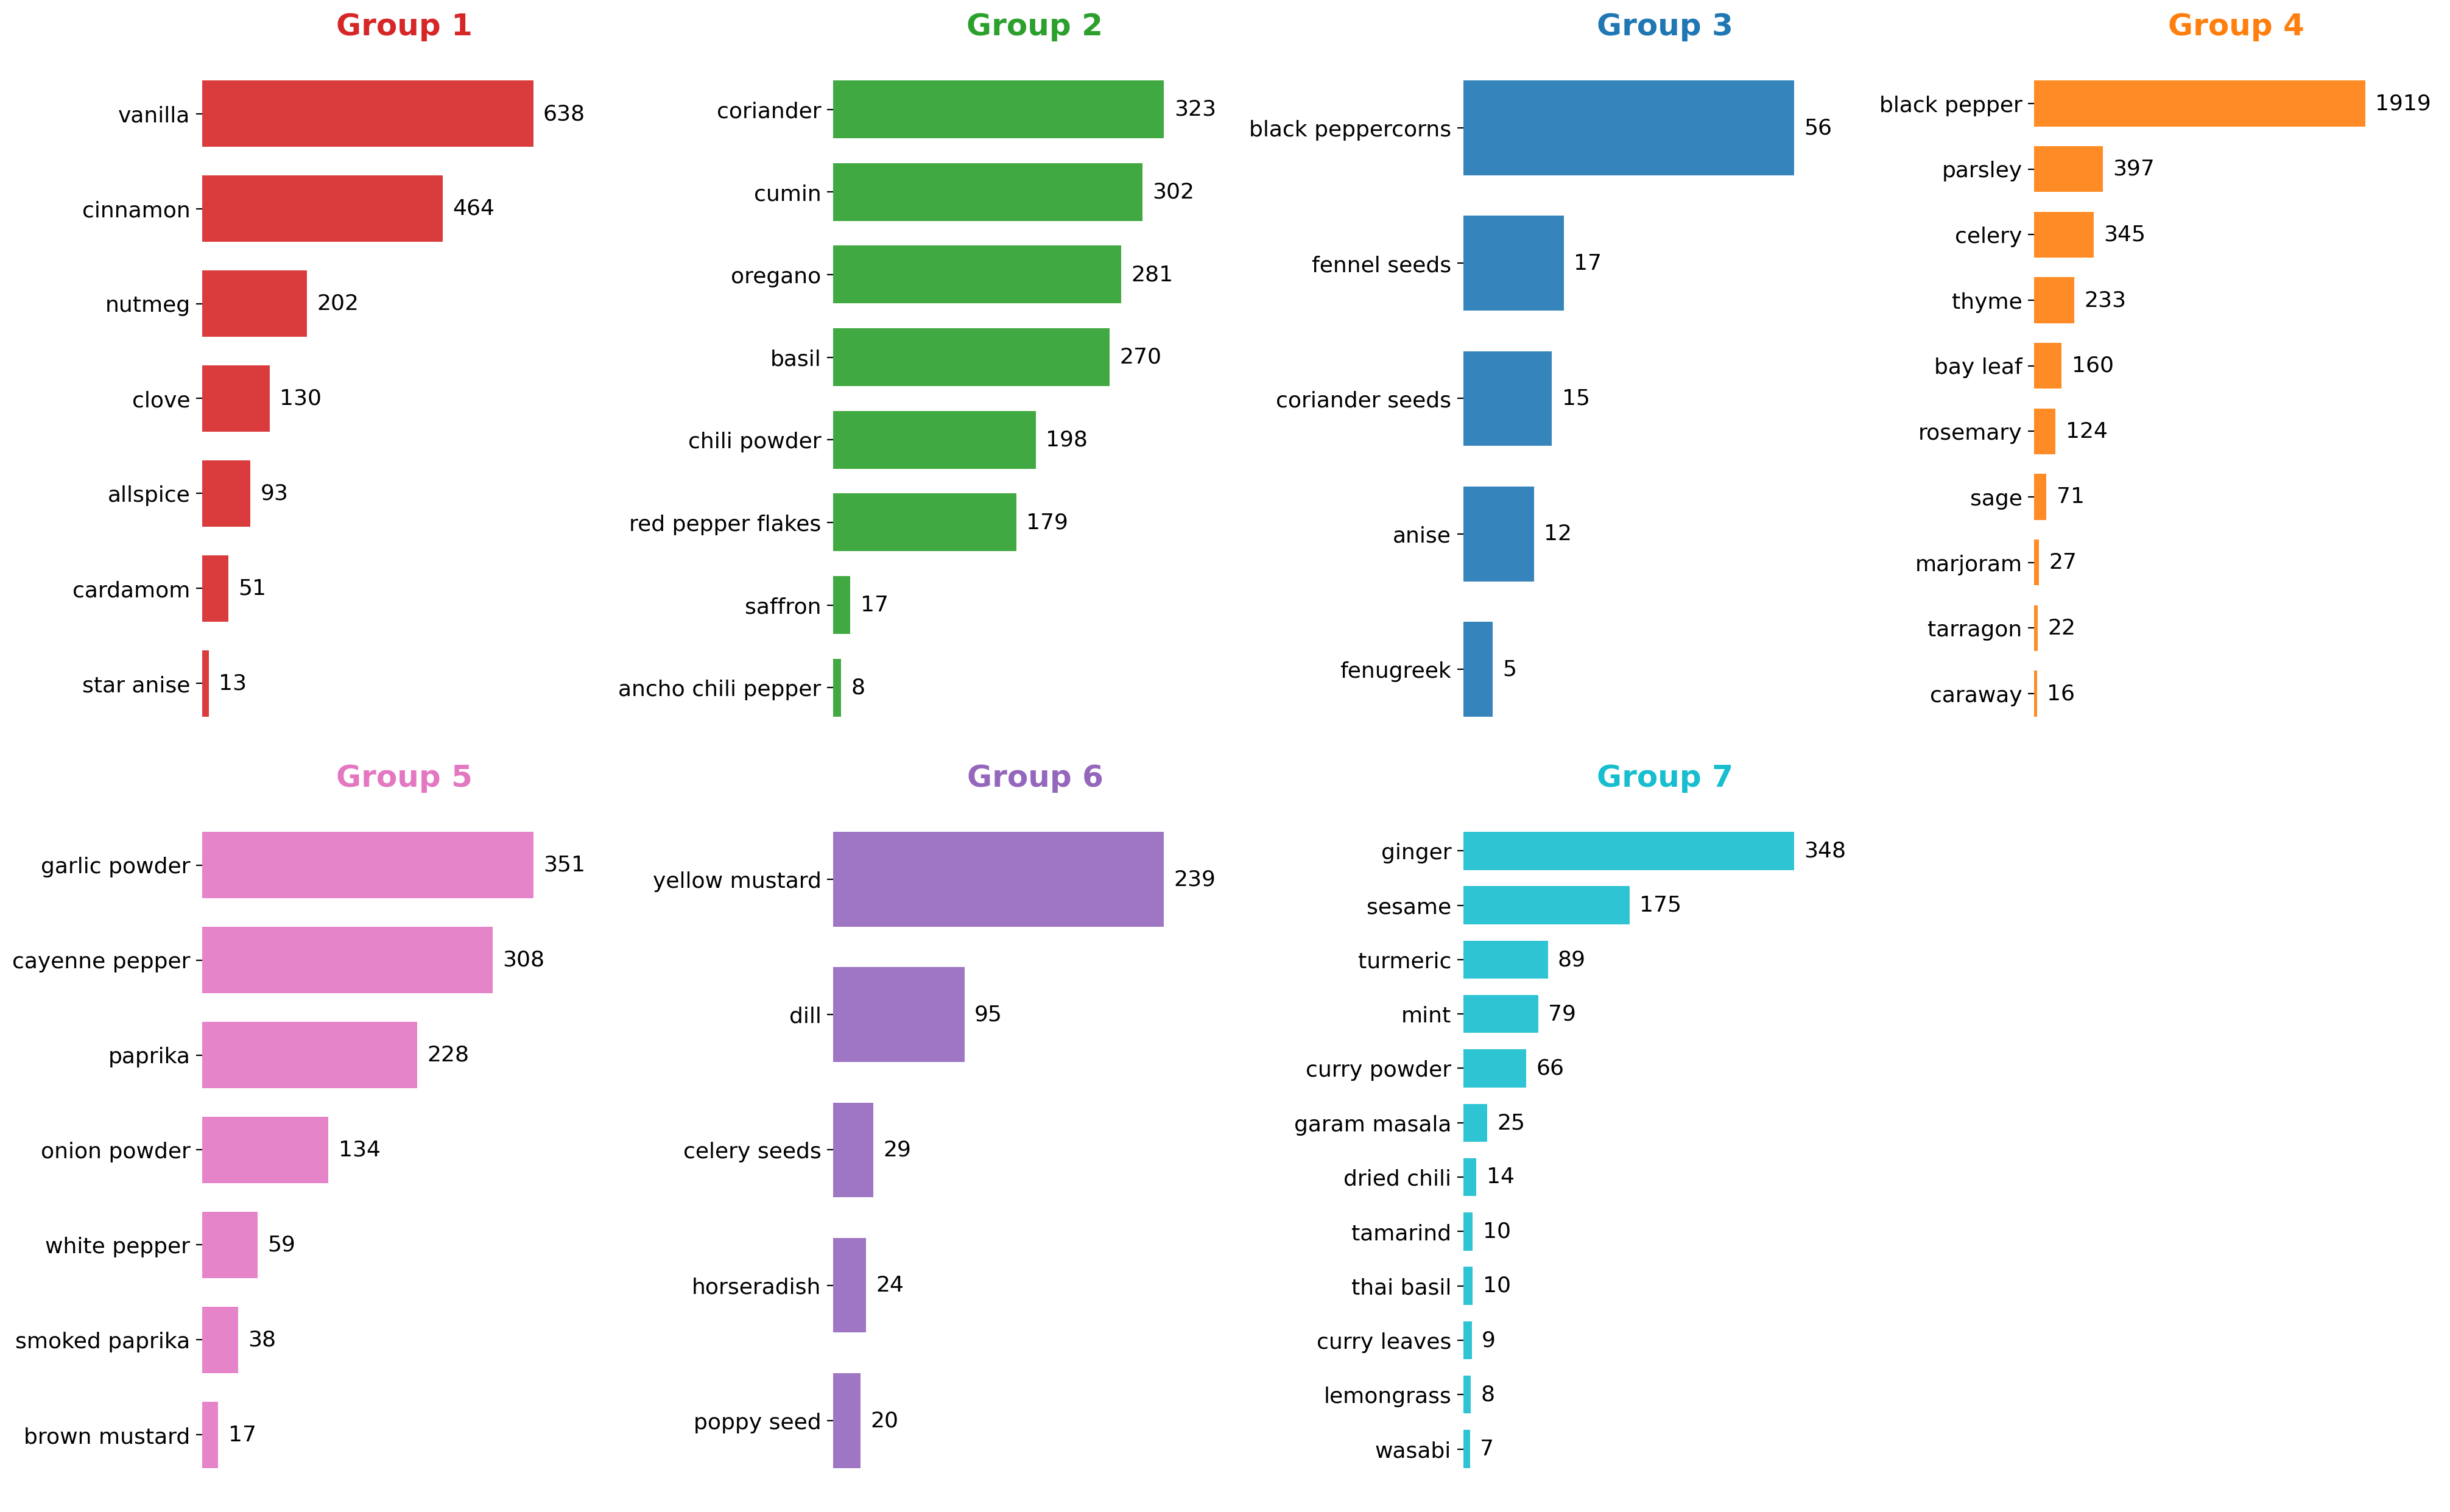

Saved: /content/drive/MyDrive/Data Mining - Final Project/Visualization 2 - Classification/spice_groups.png


In [ ]:
# === Spice communities: readable multi-row chart (ordered 1 to 7) ===
# Saves: 'spice_groups.png' and 'spice_groups.svg'

# ---------------- CONFIG (tweak here) ----------------
CSV_PATH   = r"/content/drive/MyDrive/Data Mining - Final Project/Visualization 2 - Classification/spice_partition.csv"

# Layout & sizing
MAX_COLS   = 4        # wrap into up to this many columns
COL_WIDTH  = 5.0      # inches per column
ROW_ITEM_H = 0.55     # inches per bar (row height scales with tallest panel in that row)
BAR_H      = 0.7      # bar thickness
WRAP       = 26       # wrap long spice names

# Fonts
TITLE_FS   = 18
LABEL_FS   = 13
VALUE_FS   = 13

# Output
FIG_DPI    = 300
PNG_PATH   = "/content/drive/MyDrive/Data Mining - Final Project/Visualization 2 - Classification/spice_groups.png"

# Colors per group (extend if >10)
GROUP_COLORS = [
    "#D62728", "#2CA02C", "#1F77B4", "#FF7F0E", "#E377C2", "#9467BD",
    "#17BECF", "#8C564B", "#BCBD22", "#7F7F7F"
]

# Load CSV file
df = pd.read_csv(CSV_PATH)
if "spice" not in df.columns or "community" not in df.columns:
    raise ValueError(f"Expected 'spice' and 'community' columns. Found: {list(df.columns)}")

COUNT_COL = "n_recipes"
if COUNT_COL not in df.columns:
    raise ValueError(f"Expected '{COUNT_COL}' column. Found: {list(df.columns)}")

df = df.copy()
df["spice"] = df["spice"].astype(str).str.strip()

# Community normalization
def extract_comm_num(x):
    if isinstance(x, (int, np.integer)):
        return int(x)
    if isinstance(x, float) and np.isfinite(x):
        return int(round(x))
    s = str(x)
    m = re.search(r"-?\d+", s)
    if m:
        try:
            return int(m.group(0))
        except Exception:
            return np.inf
    return np.inf

raw_nums = df["community"].apply(extract_comm_num)
if set(raw_nums.dropna().unique()).issubset(set(range(0, 7))):
    df["_comm_display"] = raw_nums + 1
else:
    df["_comm_display"] = raw_nums

df = df[df["_comm_display"].isin(range(1, 8))].copy()

# Prep data
by_comm = {}
for comm, g in df.groupby("_comm_display"):
    g = g.sort_values(COUNT_COL, ascending=False).reset_index(drop=True)
    by_comm[int(comm)] = g

order = [c for c in range(1, 8) if c in by_comm]
if not order:
    raise ValueError("No communities 1..7 found after normalization.")

n_comm = len(order)
n_cols = min(MAX_COLS, n_comm)
n_rows = math.ceil(n_comm / n_cols)

# Compute figure height row-by-row: each row height ~ tallest panel in that row
row_heights = []
for r in range(n_rows):
    cols_in_row = order[r*n_cols:(r+1)*n_cols]
    tallest = max(len(by_comm[c]) for c in cols_in_row)
    row_heights.append(max(2.2, tallest * ROW_ITEM_H))
fig_w = COL_WIDTH * n_cols
fig_h = sum(row_heights) + 0.2*(n_rows-1)  # tiny spacing between rows

fig, axes = plt.subplots(n_rows, n_cols, figsize=(fig_w, fig_h), squeeze=False, constrained_layout=True)

# Plot
for idx, comm in enumerate(order):
    r, c = divmod(idx, n_cols)
    ax = axes[r, c]
    g = by_comm[comm]

    x = g[COUNT_COL].to_numpy()[::-1]  # largest on top
    y = np.arange(len(g))[::-1]
    names = g["spice"].tolist()[::-1]
    if WRAP and WRAP > 0:
        names = [textwrap.fill(s, width=WRAP) for s in names]

    color = GROUP_COLORS[(comm - 1) % len(GROUP_COLORS)]
    ax.barh(y, x, color=color, alpha=0.9, height=BAR_H)

    ax.set_yticks(y, labels=names, fontsize=LABEL_FS)
    ax.invert_yaxis()

    xmax = float(x.max()) if len(x) else 1.0
    pad = 0.03 * xmax
    for yy, val in zip(y, x):
        ax.text(val + pad, yy, f"{int(val)}", va="center", fontsize=VALUE_FS)

    ax.set_title(f"Group {comm}", fontsize=TITLE_FS, fontweight="bold", color=color, pad=8)
    ax.set_xlim(0, xmax * 1.22)
    ax.set_xticks([])
    for spine in ax.spines.values():
        spine.set_visible(False)

# Hide any empty subplots (when groups don’t fill the last row)
for idx in range(n_comm, n_rows*n_cols):
    r, c = divmod(idx, n_cols)
    axes[r, c].axis("off")

# Save file
fig.savefig(PNG_PATH, dpi=FIG_DPI, bbox_inches="tight")
plt.show()
print(f"Saved: {PNG_PATH}")